In [1]:
import csv
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
%matplotlib inline
from collections import namedtuple, OrderedDict
import pandas as pd
import seaborn as sns
sns.set_style("white")
import MDAnalysis as mda
import math

In [2]:
def angle_between(A,B):
    mod_A_sq=0
    for i in A:
        a_1=i[0]
        a_2=i[1]
        a_3=i[2]
    
        for j in i:
            mod_A_sq=mod_A_sq+j*j 

    mod_A=math.sqrt(mod_A_sq)
    mod_B=math.sqrt((B[0])**2+(B[1])**2+(B[2])**2)
    A_dot_B=a_1*B[0]+a_2*B[1]+a_3*B[2]
    cos_theta=A_dot_B/mod_A*mod_B
    #theta=math.acos(cos_theta)
    return cos_theta

In [3]:
def vector_angle(u,savename):
    B = [0,0,1]
    Data=[]
    time = []
    for ts in u.trajectory:
        atom1 = u.select_atoms("resid 19 and name CE1").positions
        atom2 = u.select_atoms("resid 19 and name CE2").positions
        A = atom1 - atom2
        angle = angle_between(A,B)
        Data.append(angle)
        time.append(ts.frame/10)
        #Data.append([frame,angle])
    df = pd.DataFrame({'Time': time, 'Cosine': Data})
    df.to_csv(savename + '.csv', sep='\t', index=False, header=True)

In [5]:
def plot_phe26_CE1_CE2(df1, df2, save_name):
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    plt.plot(df1['Time'][:5000], df1['Cosine'][:5000],color="blue",alpha=0.15)
    rolling_avg_df1 = df1['Cosine'].rolling(window=50).mean()
    plt.plot(df1['Time'][:5000], rolling_avg_df1[:5000], color="blue", label=r"without Ca$^{2+}$")
    plt.plot(df2['Time'][:5000], df2['Cosine'][:5000], color="red", alpha=0.15)
    rolling_avg_df2 = df2['Cosine'].rolling(window=50).mean()
    plt.plot(df2['Time'][:5000], rolling_avg_df2[:5000], color="red", label=r"with Ca$^{2+}$")

    ax.set_xlabel("Time (ns)", fontsize=22)
    plt.xticks(fontsize=20)
    ax.set_ylabel(r'$\cos\alpha$', fontsize=22)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    #plt.legend(fontsize=20)
    plt.savefig(save_name, dpi=300)
    plt.show()

In [5]:
u_neutral = mda.Universe("../../Neutral-without-calcium.gro","../../Neutral-without-Calcium.xtc")
u_neutral_ca = mda.Universe("../../Neutral-with-Ca.gro","../../Neutral-with-Ca.xtc")

u_two = mda.Universe("../../+2-without-calcium.gro","../../+2-without-calcium.xtc")
u_two_ca = mda.Universe("../../+2-with-Ca.gro","../../+2-with-Ca.xtc")

u_four = mda.Universe("../../+4-without-calcium.gro","../../+4-without-calcium.xtc")
u_four_ca = mda.Universe("../../+4-with-Ca.gro","../../+4-with-Ca.xtc")

u_five = mda.Universe("../../+5-without-calcium.gro","../../+5-without-calcium.xtc")
u_five_ca = mda.Universe("../../+5-with-Ca.gro","../../+5-with-Ca.xtc")

In [7]:
vector_angle(u_neutral,"Neutral")
vector_angle(u_neutral_ca,"Neutral_Calcium")

vector_angle(u_two,"Two")
vector_angle(u_two_ca,"Two_Calcium")

vector_angle(u_four,"Four")
vector_angle(u_four_ca,"Four_Calcium")

vector_angle(u_five,"Five")
vector_angle(u_five_ca,"Five_Calcium")

In [2]:
df_neutral_cos = pd.read_csv("Neutral.csv",delimiter='\t')
df_neutral_ca_cos = pd.read_csv("Neutral_Calcium.csv",delimiter='\t')

df_two_cos = pd.read_csv("Two.csv",delimiter='\t')
df_two_ca_cos = pd.read_csv("Two_Calcium.csv",delimiter='\t')

df_four_cos = pd.read_csv("Four.csv",delimiter='\t')
df_four_ca_cos = pd.read_csv("Four_Calcium.csv",delimiter='\t')

df_five_cos = pd.read_csv("Five.csv",delimiter='\t')
df_five_ca_cos = pd.read_csv("Five_Calcium.csv",delimiter='\t')

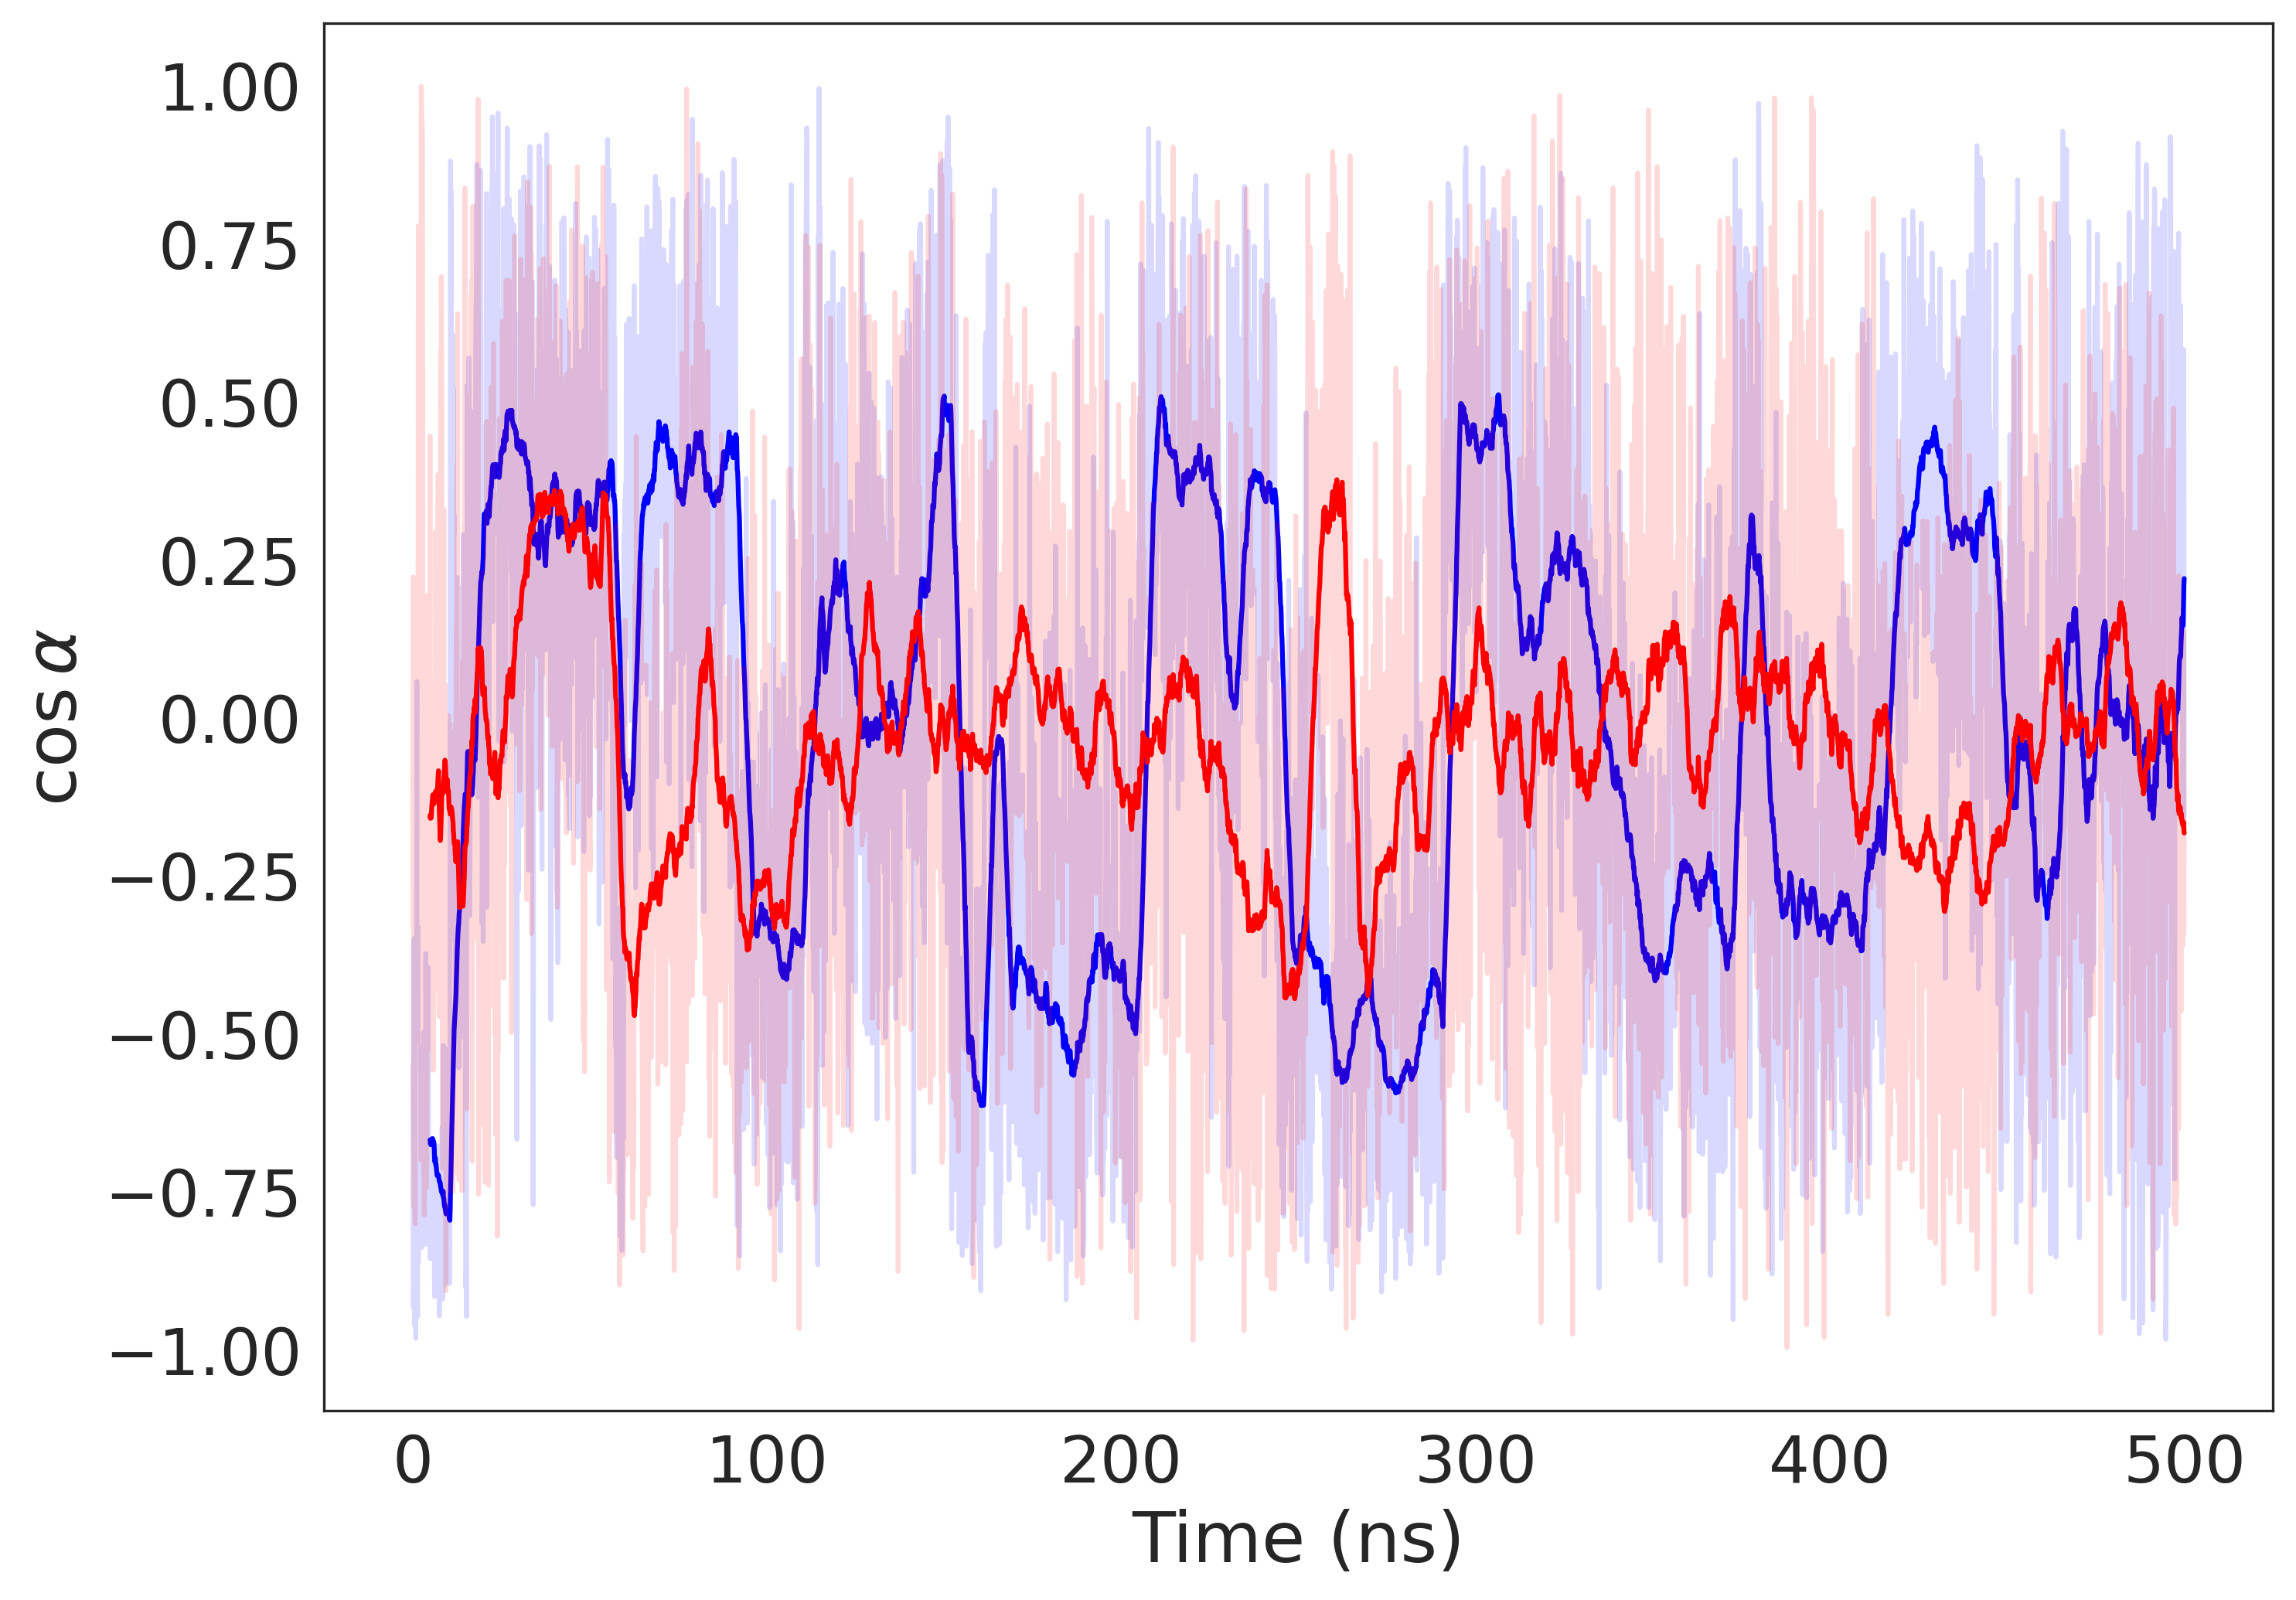

In [6]:
plot_phe26_CE1_CE2(df_neutral_cos,df_neutral_ca_cos,"Neutral_CE1_CE2.pdf")

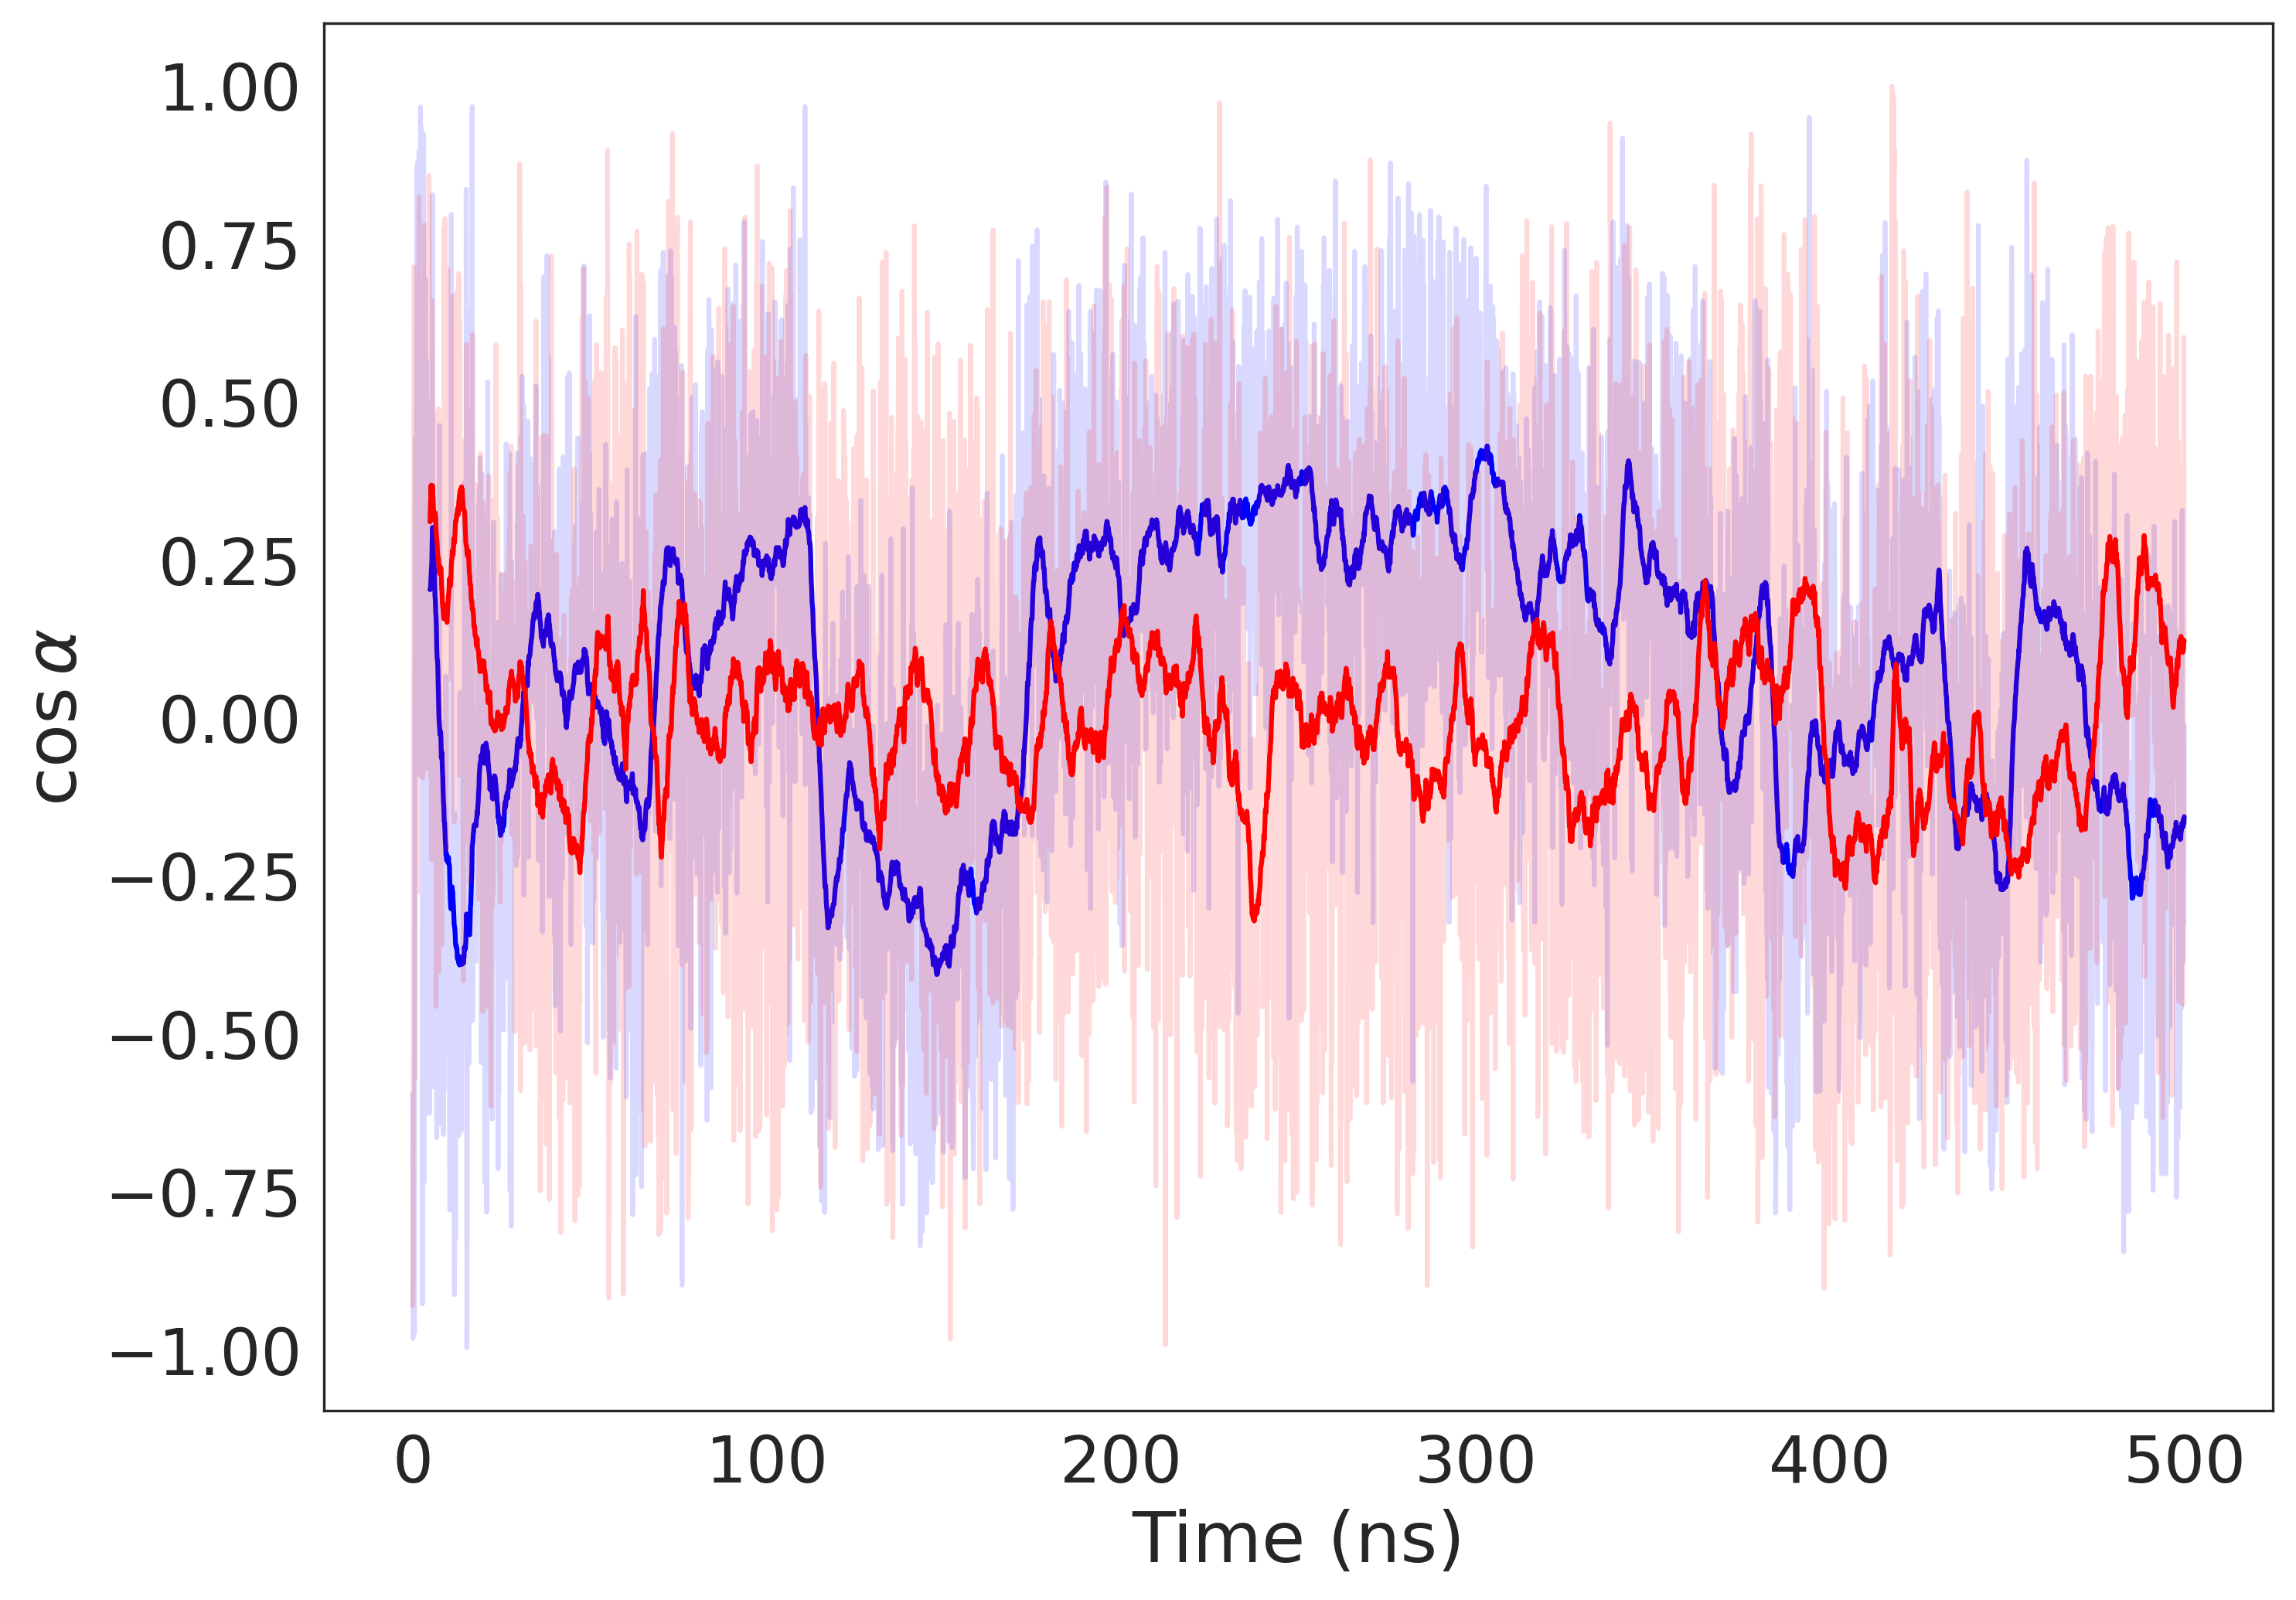

In [7]:
plot_phe26_CE1_CE2(df_two_cos,df_two_ca_cos,"Two_CE1_CE2.pdf")

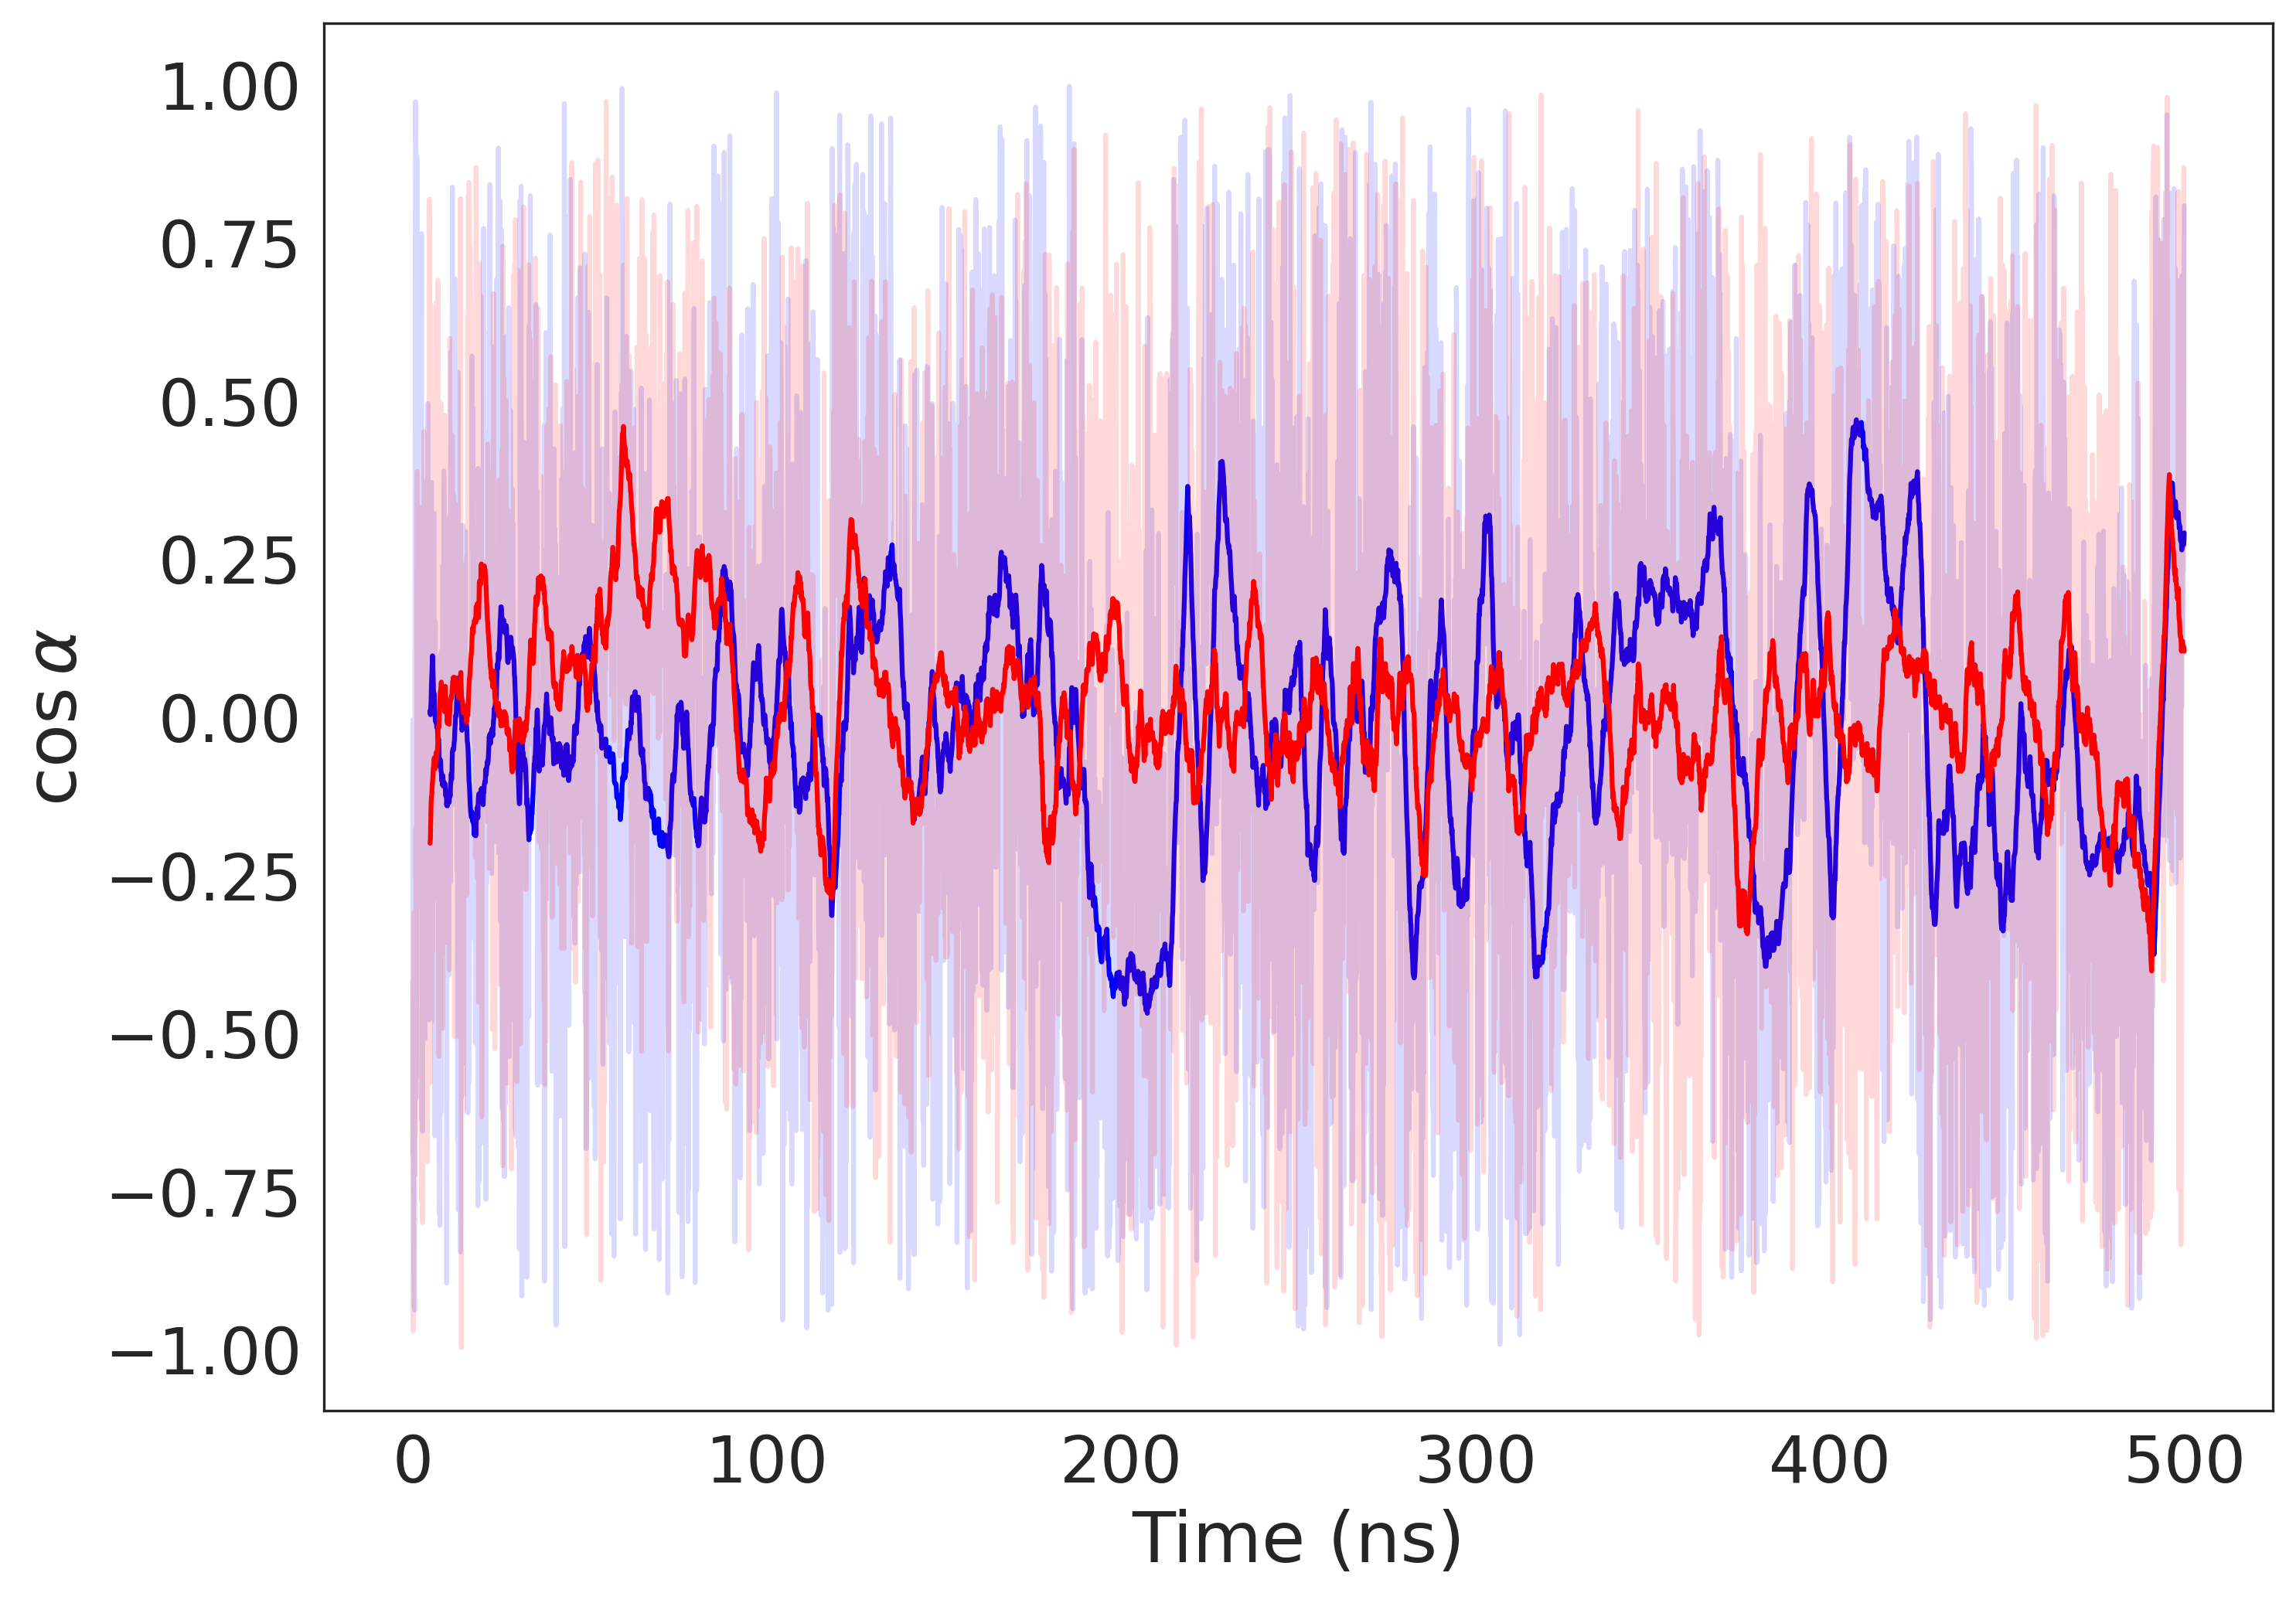

In [9]:
plot_phe26_CE1_CE2(df_four_cos,df_four_ca_cos,"Four_CE1_CE2.pdf")

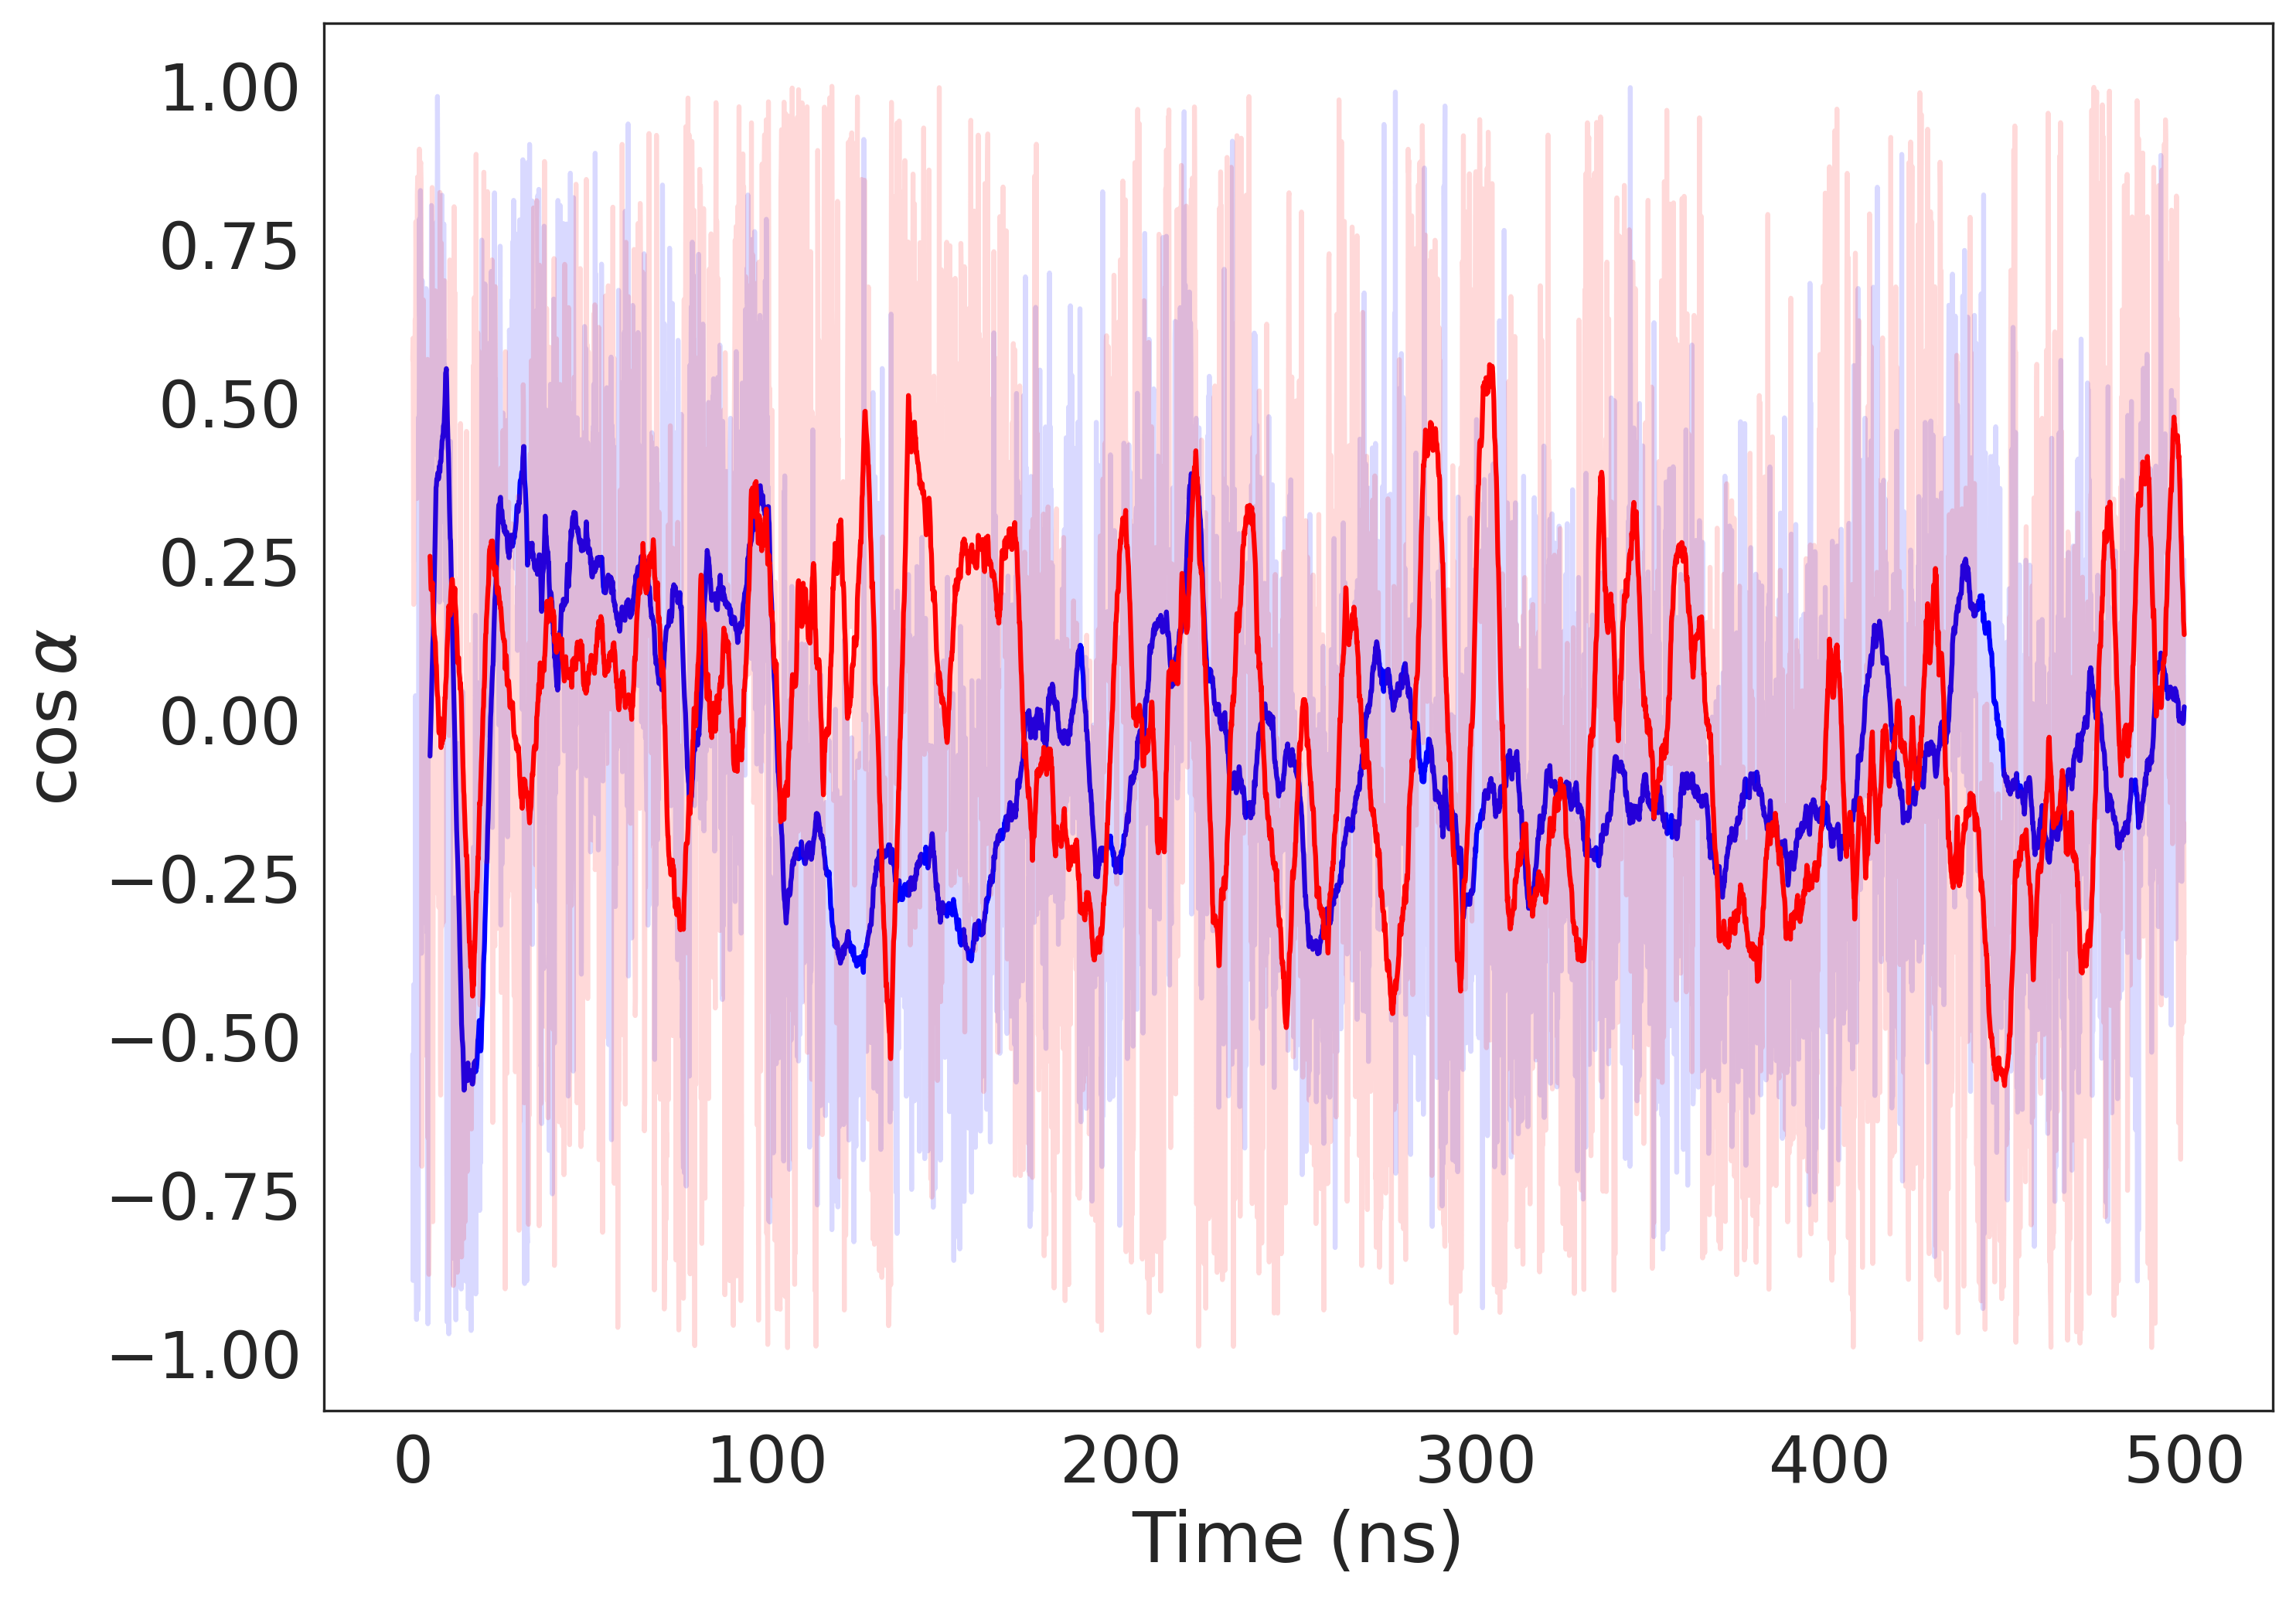

In [8]:
plot_phe26_CE1_CE2(df_five_cos,df_five_ca_cos,"Five_CE1_CE2.pdf")

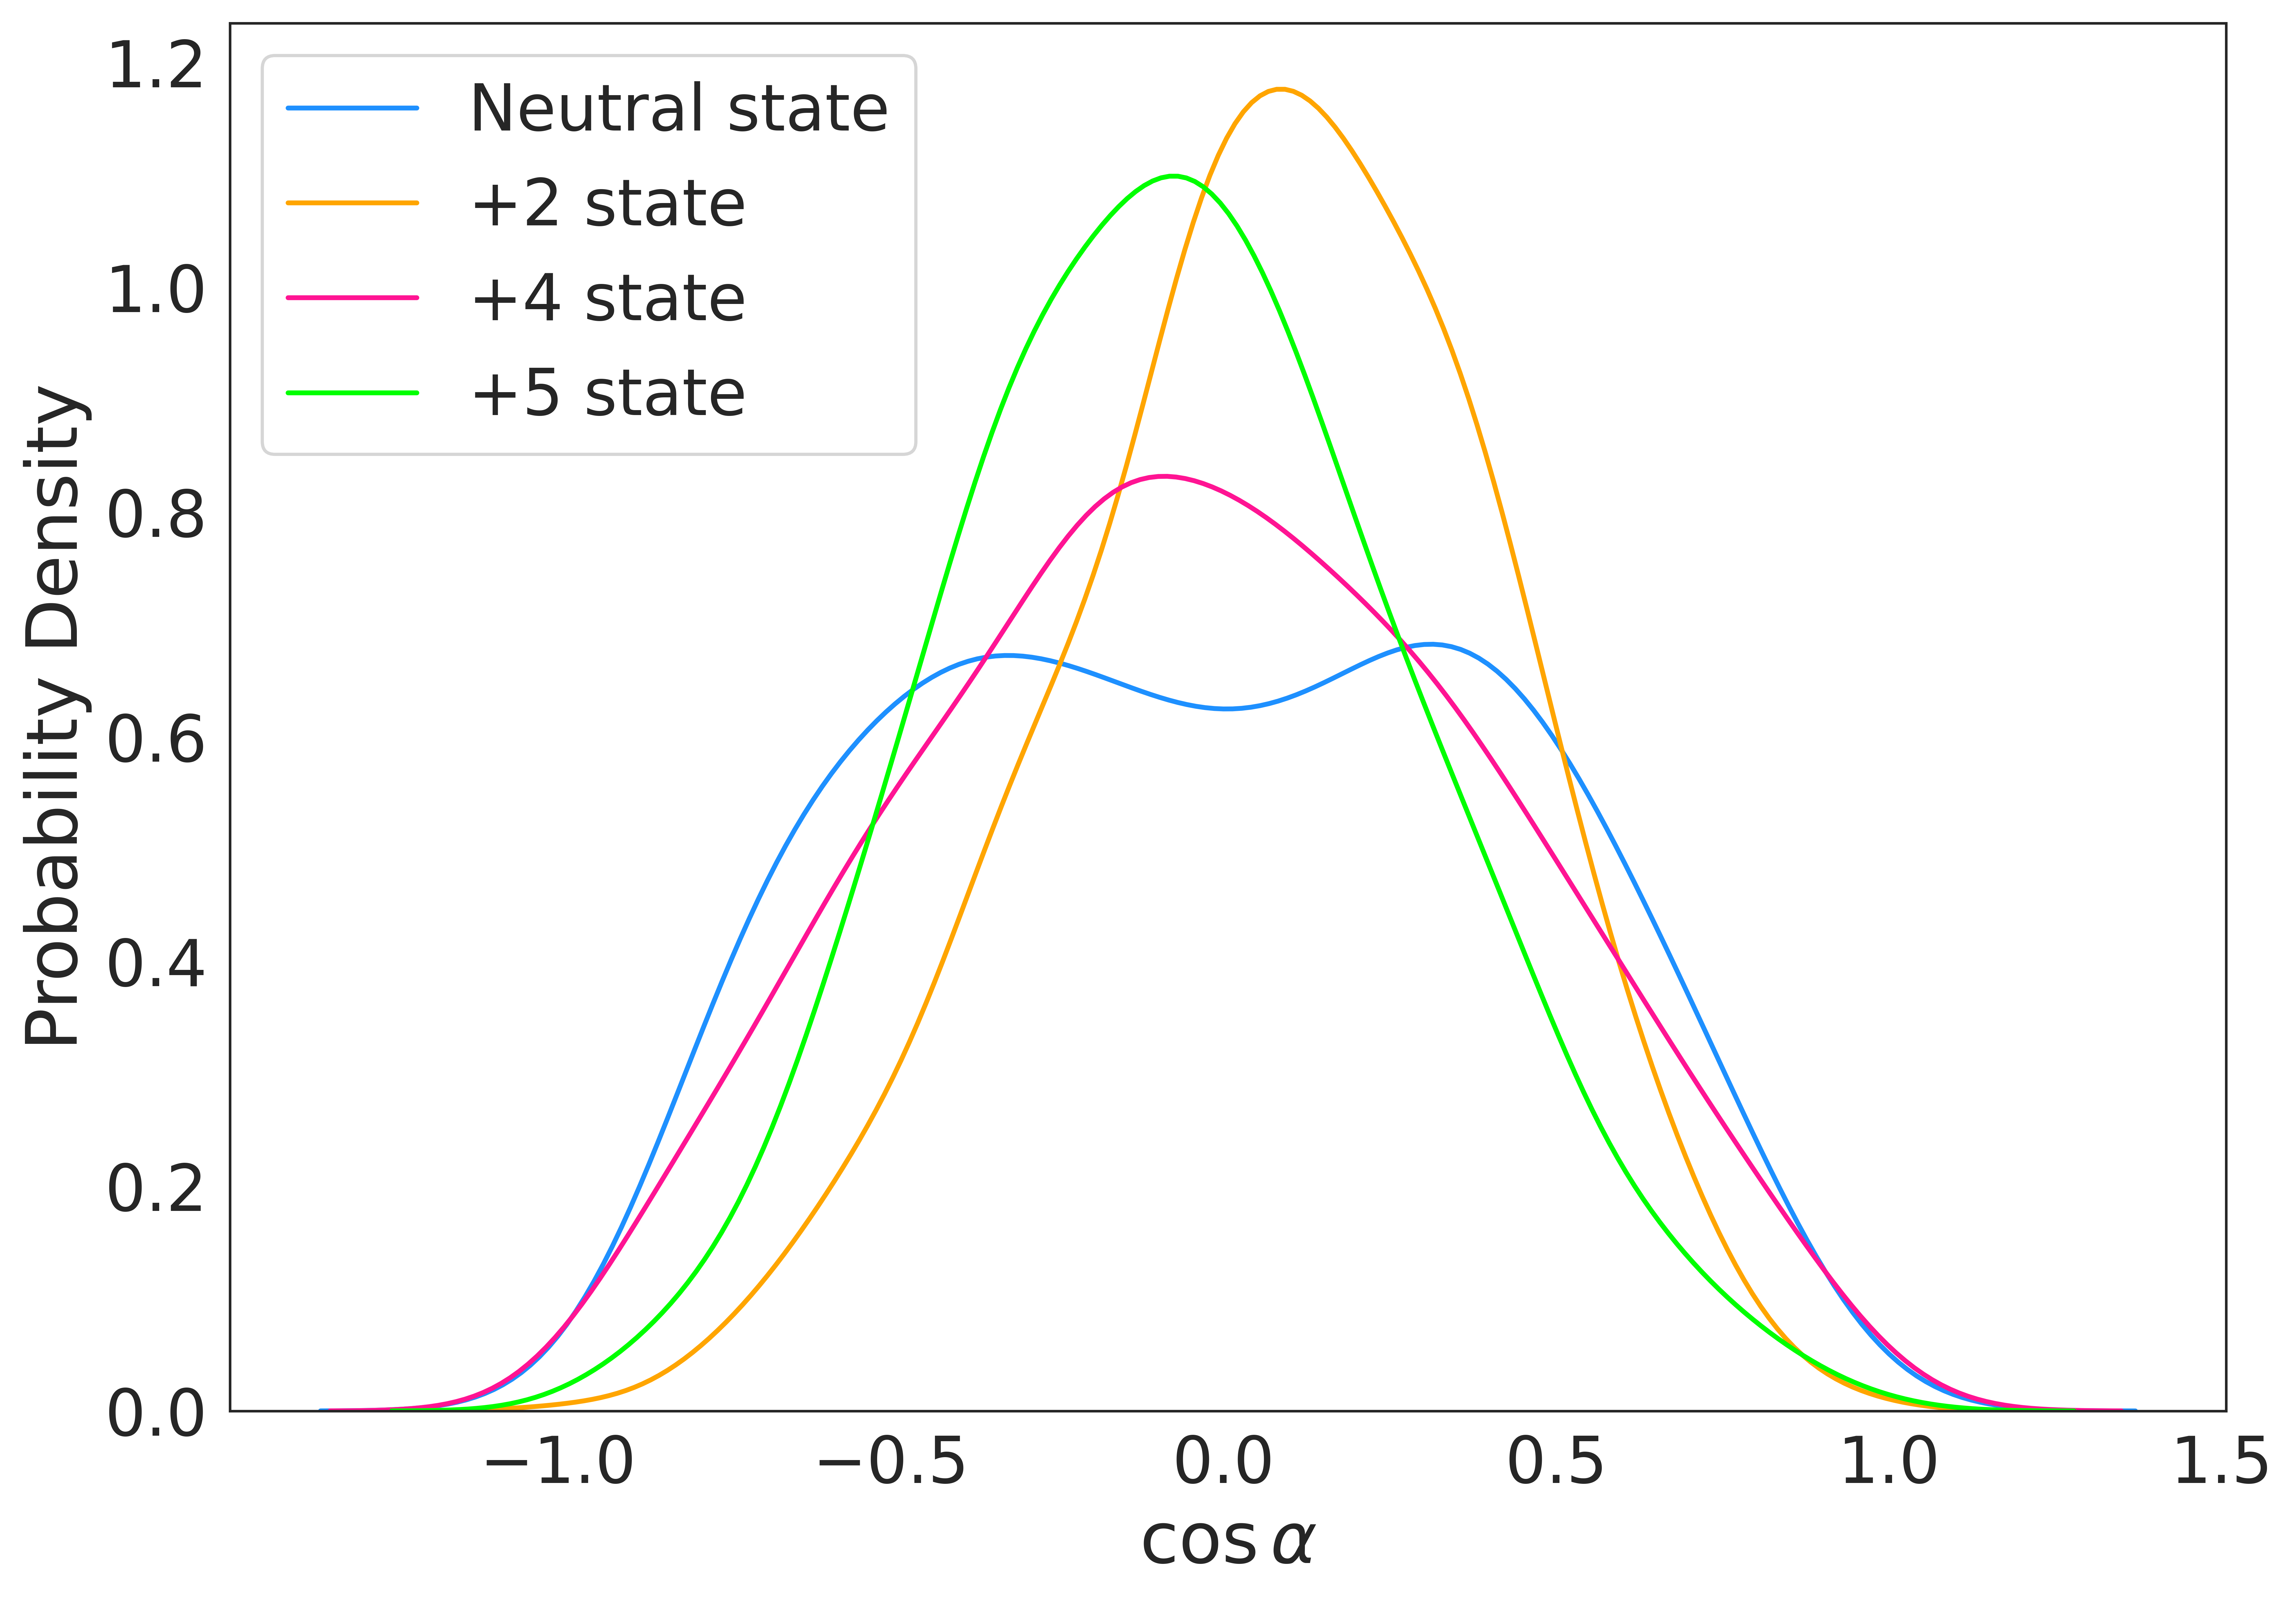

In [3]:
kwargs = dict(bw_adjust=1.5)
fig = plt.figure(figsize=(10, 7), dpi=800)
sns.kdeplot(df_neutral_cos['Cosine'][:5000], color="dodgerblue", label="Neutral state", **kwargs)
sns.kdeplot(df_two_cos['Cosine'][:5000], color="orange", label="+2 state", **kwargs)
sns.kdeplot(df_four_cos['Cosine'][:5000], color="deeppink", label="+4 state", **kwargs)
sns.kdeplot(df_five_cos['Cosine'][:5000], color="#00FF00", label="+5 state", **kwargs)
plt.xlabel(r'$\cos\alpha$', fontsize=22)
plt.xticks(fontsize=20)
plt.ylabel('Probability Density', fontsize=22)
plt.yticks(fontsize=20)
plt.legend(loc='upper left', fontsize=20)
fig.tight_layout()
plt.savefig('without_Calcium_ion_seaborn_plot_CE1_CE2.png', dpi=500, bbox_inches='tight')
plt.savefig('without_Calcium_ion_seaborn_plot_CE1_CE2.pdf', dpi=500, bbox_inches='tight')
plt.show()

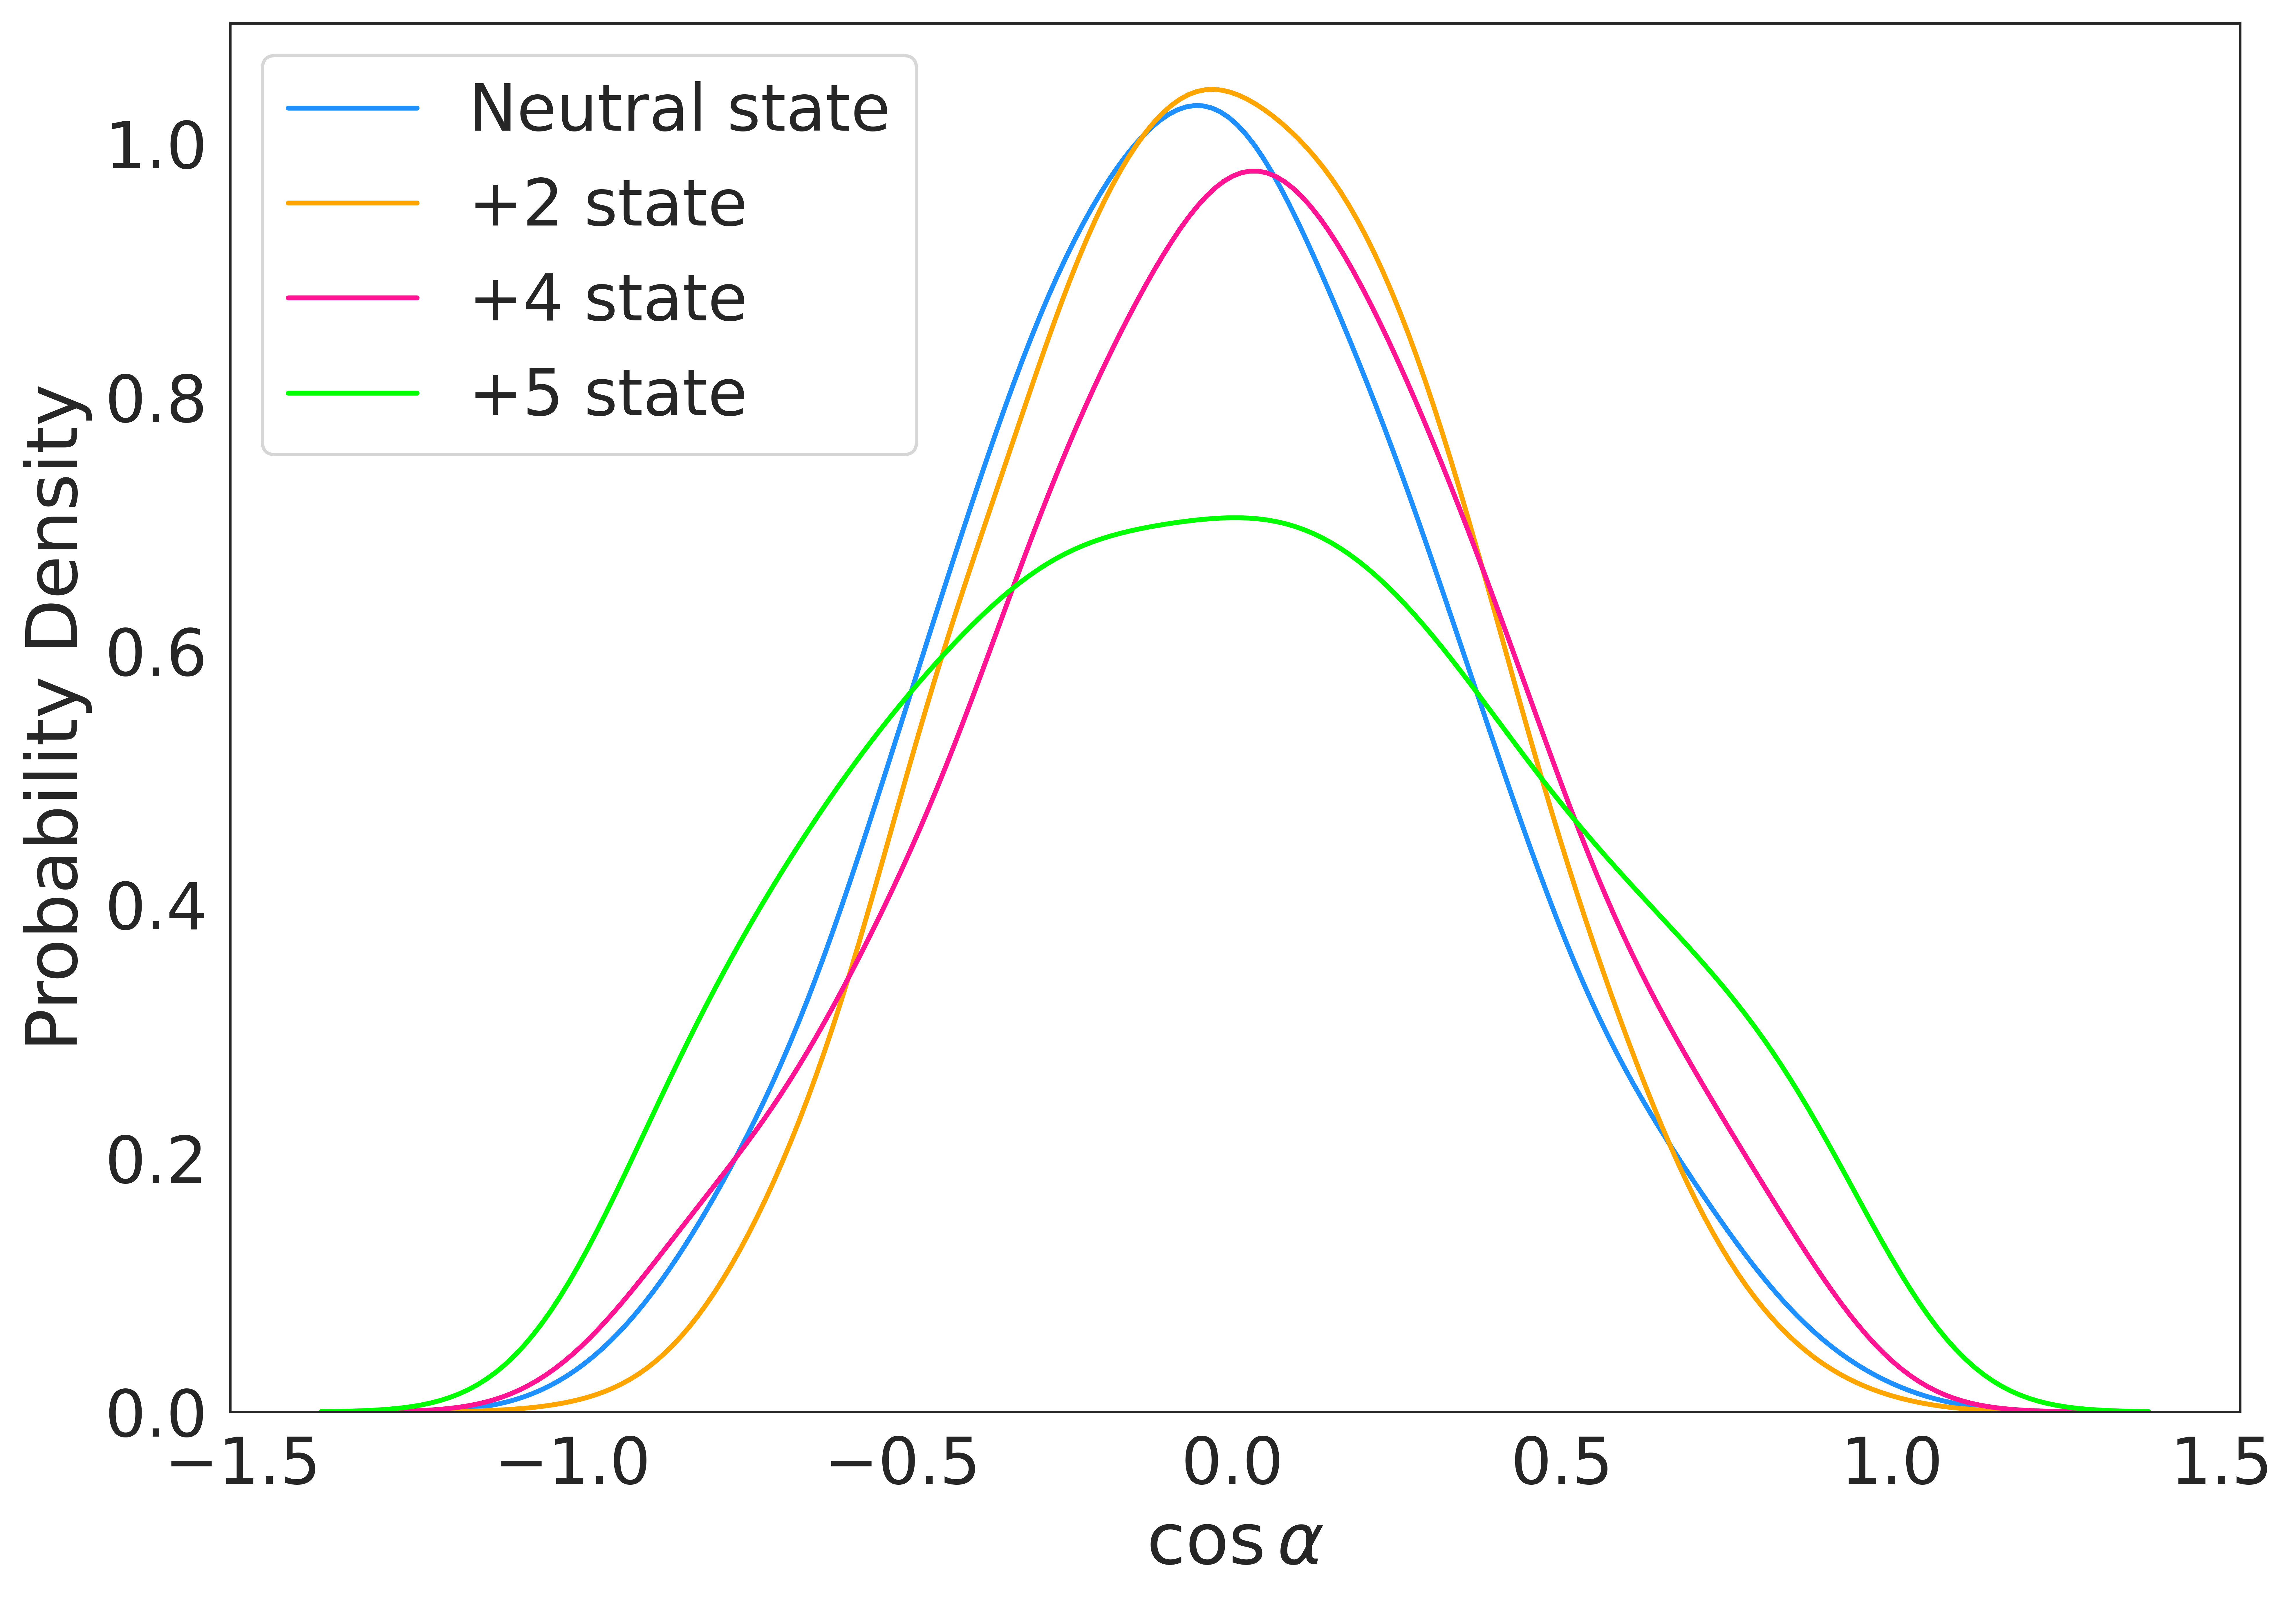

In [4]:
kwargs = dict(bw_adjust=1.5)
fig = plt.figure(figsize=(10, 7), dpi=800)
sns.kdeplot(df_neutral_ca_cos['Cosine'][:5000], color="dodgerblue", label="Neutral state", **kwargs)
sns.kdeplot(df_two_ca_cos['Cosine'][:5000], color="orange", label="+2 state", **kwargs)
sns.kdeplot(df_four_ca_cos['Cosine'][:5000], color="deeppink", label="+4 state", **kwargs)
sns.kdeplot(df_five_ca_cos['Cosine'][:5000], color="#00FF00", label="+5 state", **kwargs)
plt.xlabel(r'$\cos\alpha$', fontsize=22)
plt.xticks(fontsize=20)
plt.ylabel('Probability Density', fontsize=22)
plt.yticks(fontsize=20)
plt.legend(loc='upper left', fontsize=20)
fig.tight_layout()
plt.savefig('with_Calcium_ion_seaborn_plot_CE1_CE2.png', dpi=500, bbox_inches='tight')
plt.savefig('with_Calcium_ion_seaborn_plot_CE1_CE2.pdf', dpi=500, bbox_inches='tight')
plt.show()

In [53]:
from scipy.signal import find_peaks
import scipy.stats as stats

def plot_with_peak_detection(df):
    x_values = np.linspace(min(df['Cosine']), max(df['Cosine']), 1000)
    fig, ax = plt.subplots(figsize=(10, 7), dpi=800)
    sns.kdeplot(df['Cosine'], color="dodgerblue", label="Neutral state", **kwargs)
    kde = stats.gaussian_kde(df['Cosine'])
    peaks, _ = find_peaks(kde(x_values), height=0.05)
    peak_xs = x_values[peaks]

    for peak_x in peak_xs:
        plt.plot(peak_x, kde(peak_x), 'o', color='red')
    for peak_x in peak_xs:
        plt.text(peak_x, kde(peak_x), f"Peak: {peak_x:.3f}", color='red', fontsize=12, verticalalignment='bottom')
    plt.xlabel(r'$\cos\theta$', fontsize=22)
    plt.ylabel('Probability Density', fontsize=22)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(loc='upper left', fontsize=15)
    plt.show()
# plot_with_peak_detection(df_neutral_cos)

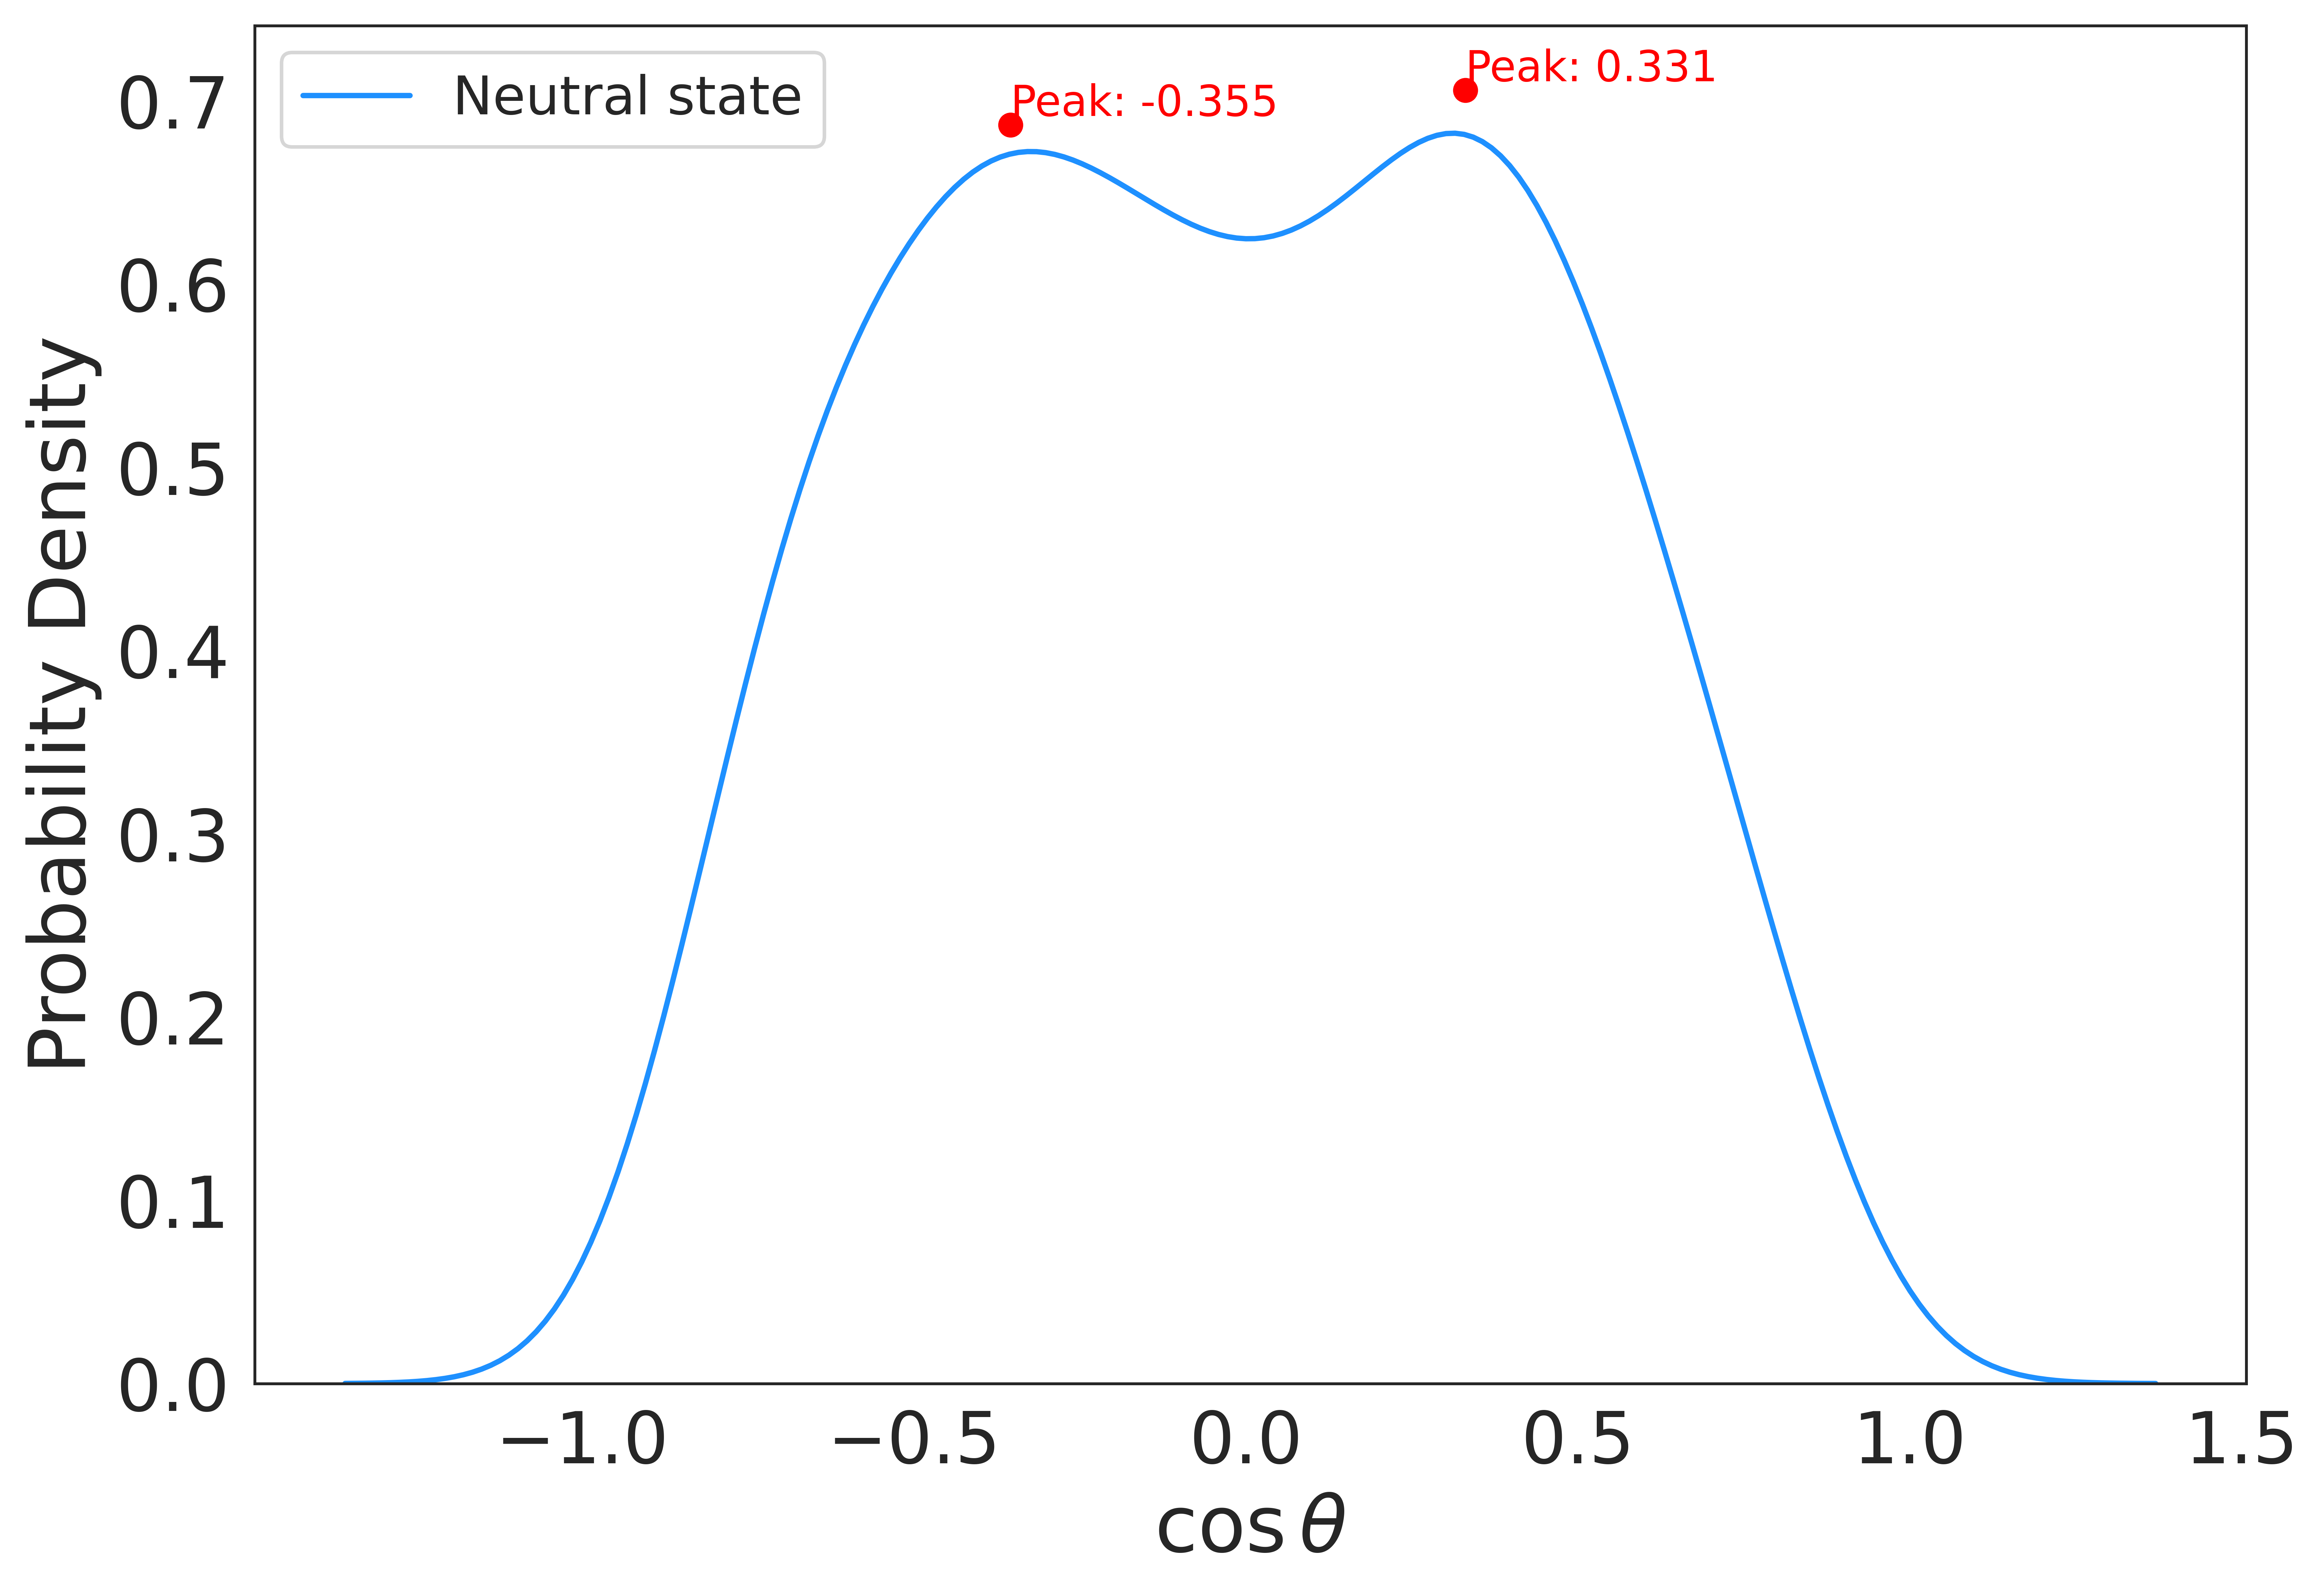

In [54]:
plot_with_peak_detection(df_neutral_cos[:5000])

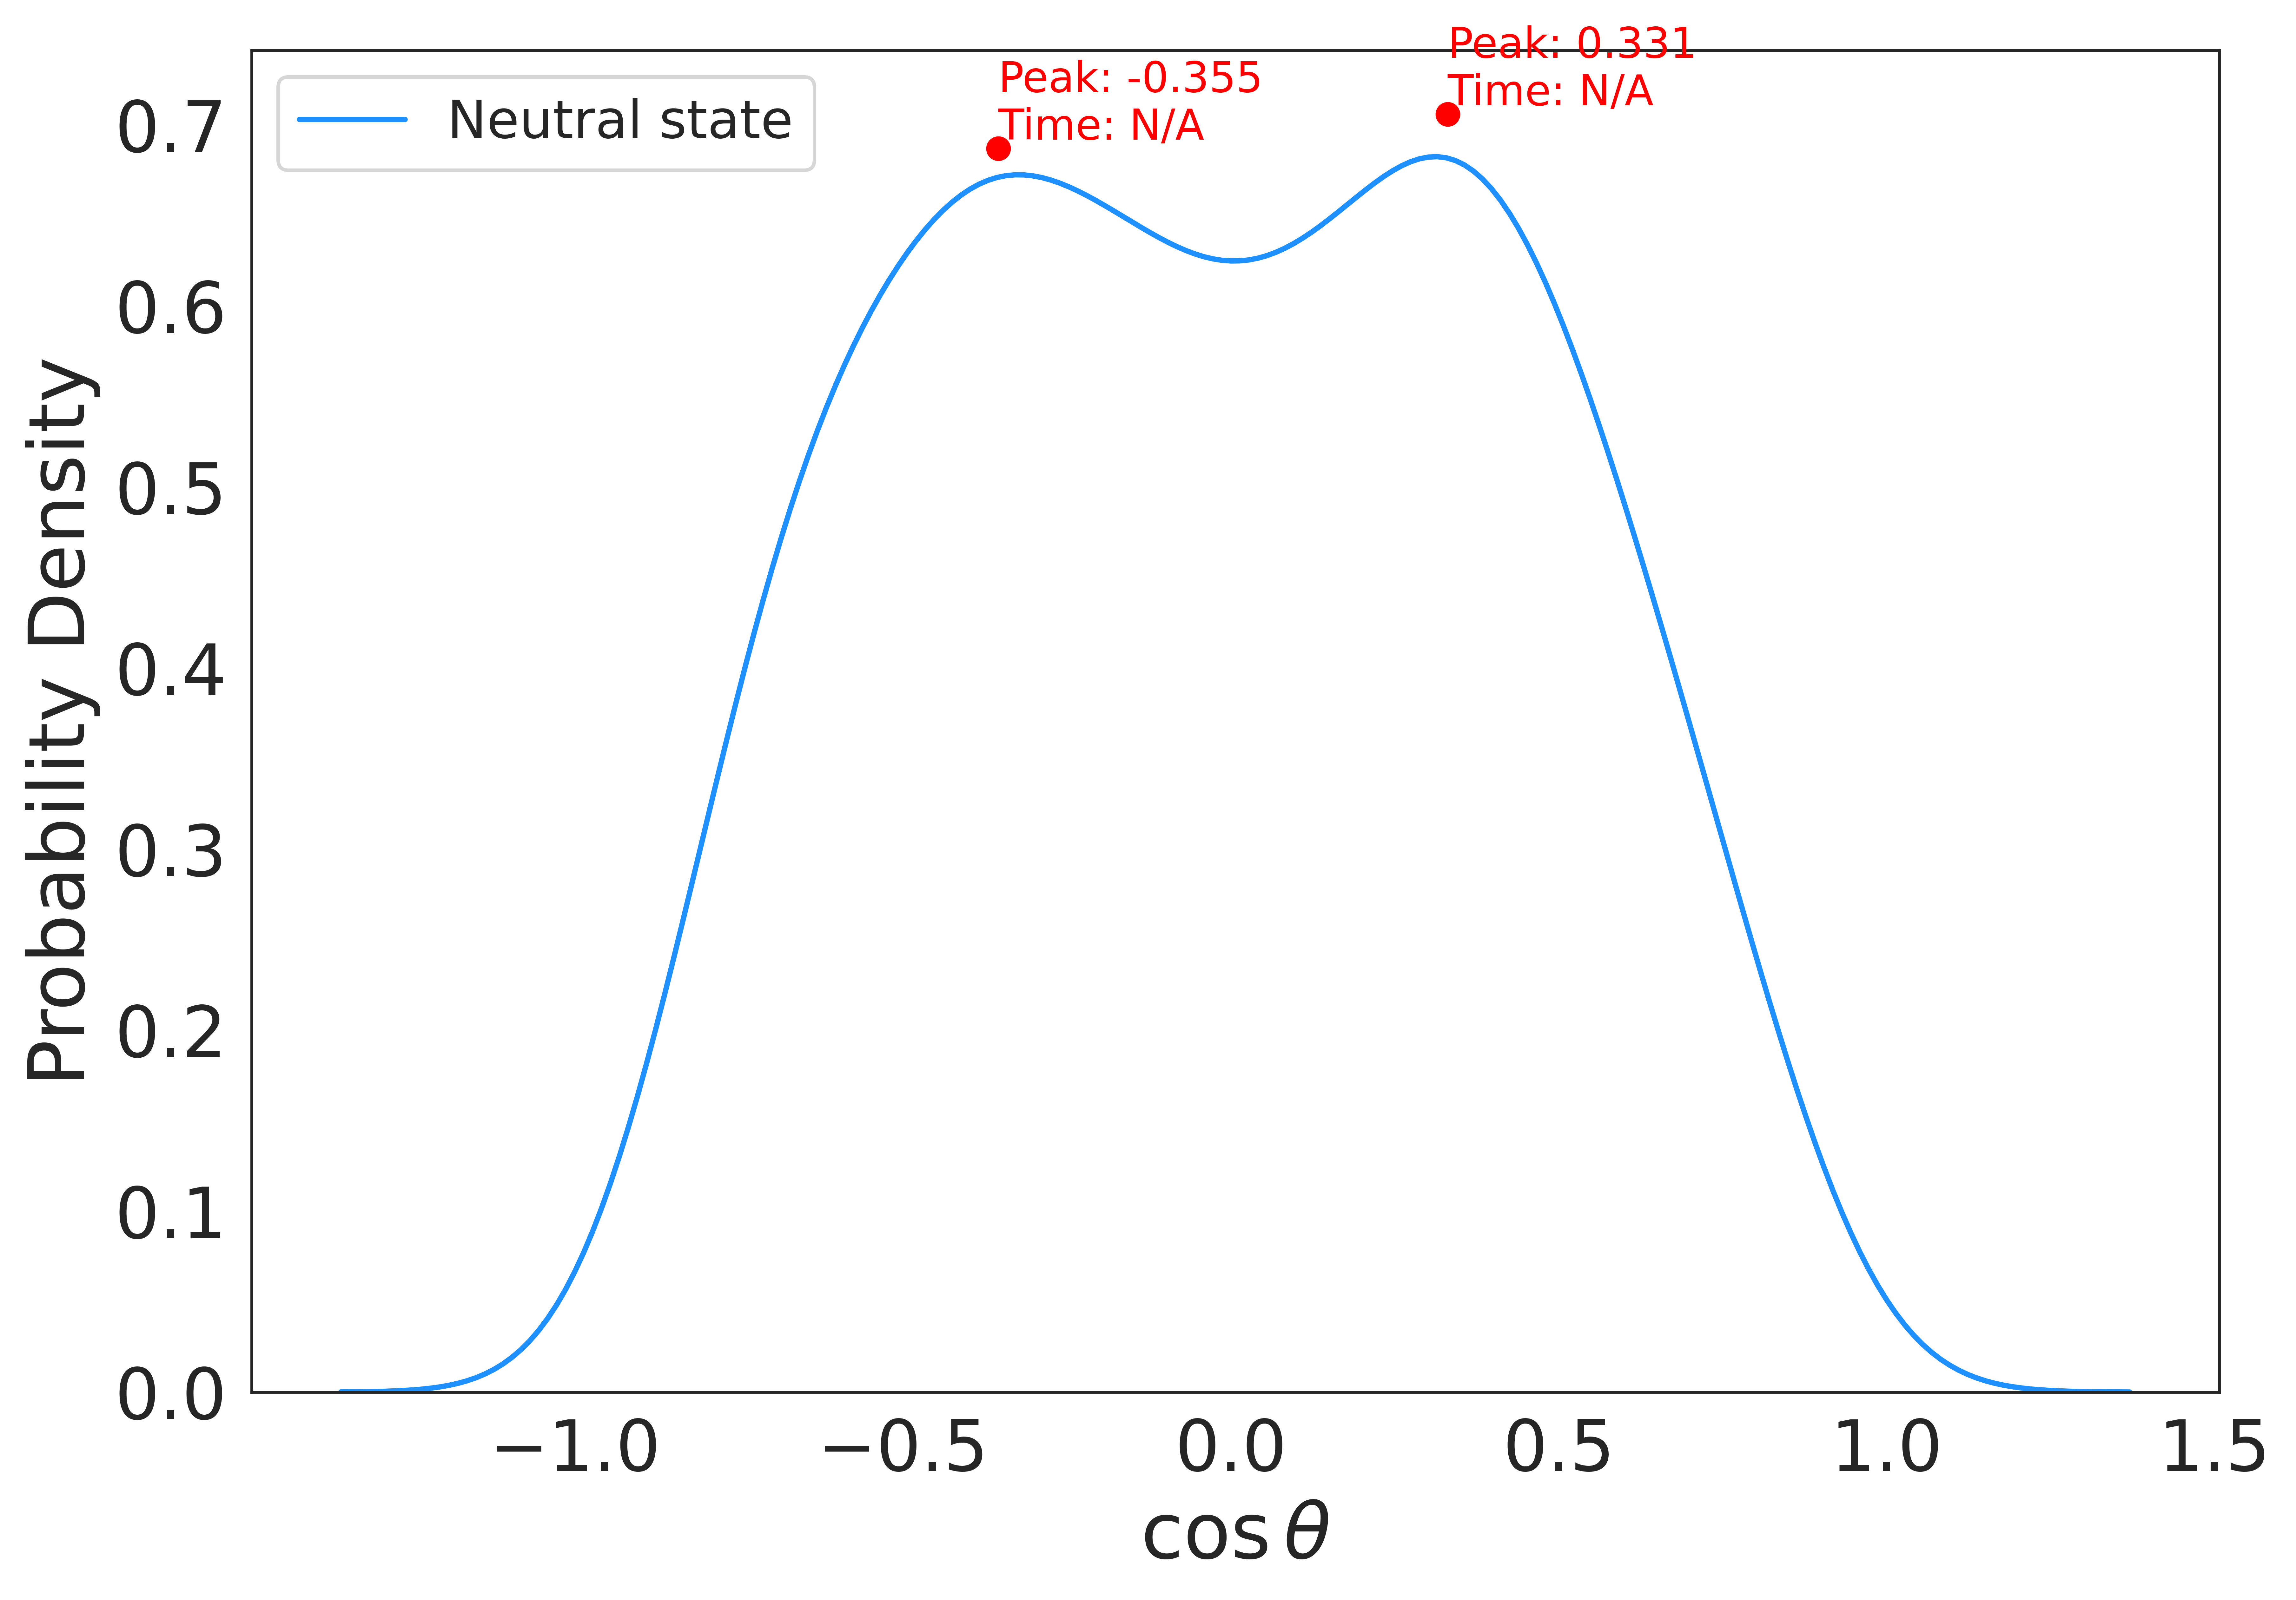

In [58]:
plot_with_peak_detection(df_neutral_cos[:5000])

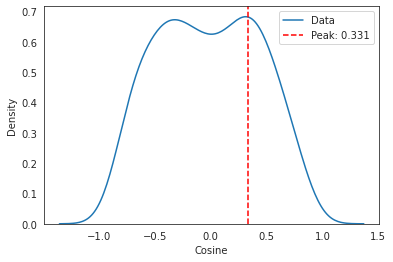

In [62]:
from scipy.signal import find_peaks
import scipy.stats as stats

data = np.random.normal(loc=0, scale=1, size=1000)

g = df_neutral_cos['Cosine'][:5000]
sns.kdeplot(g, label="Data",bw_adjust=1.5)
kde = stats.gaussian_kde(g)
x_values = np.linspace(min(g), max(g), 1000)
peak_x = x_values[np.argmax(kde(x_values))]
plt.axvline(x=peak_x, color='r', linestyle='--', label=f'Peak: {peak_x:.3f}')

plt.legend()
plt.show()

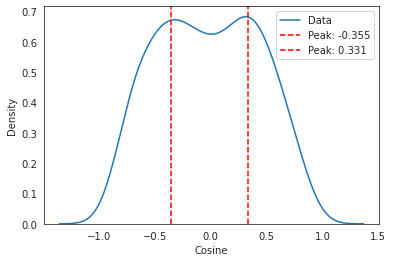

Corresponding Time value for peak Cosine value -0.355: 144.4
Corresponding Time value for peak Cosine value 0.331: 63.9


In [63]:
from scipy.signal import find_peaks
import scipy.stats as stats

data = np.random.normal(loc=0, scale=1, size=1000)

g = df_neutral_cos['Cosine'][:5000]

sns.kdeplot(g, label="Data", bw_adjust=1.5)
kde = stats.gaussian_kde(g)

x_values = np.linspace(min(g), max(g), 1000)
peaks, _ = find_peaks(kde(x_values), height=0.05)
peak_xs = x_values[peaks]


for peak_x in peak_xs:
    plt.axvline(x=peak_x, color='r', linestyle='--', label=f'Peak: {peak_x:.3f}')

plt.legend()
plt.show()


for peak_x in peak_xs:
    peak_time = df_neutral_cos.loc[df_neutral_cos['Cosine'].round(3) == peak_x.round(3), 'Time'].values[0]
    print(f"Corresponding Time value for peak Cosine value {peak_x:.3f}: {peak_time}")

In [76]:
from scipy.signal import find_peaks
import scipy.stats as stats

def detect_and_plot_peaks(df):
    g = df['Cosine']

    sns.kdeplot(g, label="Data", bw_adjust=1.5)
    kde = stats.gaussian_kde(g)

    x_values = np.linspace(min(g), max(g), 1000)
    peaks, _ = find_peaks(kde(x_values), height=0.05)
    peak_xs = x_values[peaks]

    for peak_x in peak_xs:
        plt.axvline(x=peak_x, color='r', linestyle='--', label=f'Peak: {peak_x:.3f}')

    plt.legend()
    plt.show()

    for peak_x in peak_xs:
        peak_time = df.loc[df['Cosine'].round(3) == peak_x.round(3), 'Time'].values[0]
        print(f"Corresponding Time value for peak Cosine value {peak_x:.3f}: {peak_time}")

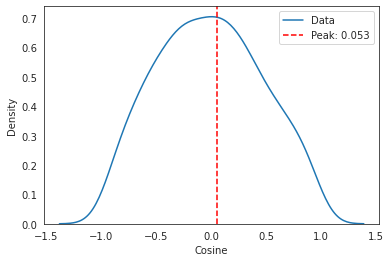

Corresponding Time value for peak Cosine value 0.053: 122.5


In [80]:
detect_and_plot_peaks(df_five_ca_cos[:5000])

In [95]:
print(f"{np.mean(df_five_ca_cos['Cosine'][:5000]):.3f}")

-0.015
